# Análisis exploratorio - Dataset NKE (Nike Stock)

**Materia:** Métodos de Análisis de Datos 1  
**Alumno:** Lucas Calierno  

---

## Objetivo
Realizar la carga y exploración inicial de un dataset en formato CSV.

---

## Paso 1: Carga de Datos

In [61]:
#Importacion de librerias
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

print("librerias importadas correctamente")

librerias importadas correctamente


### Exploracion inicial

In [62]:
#Lectura de primeras 10 lineas
df = pd.read_csv("NKE.csv")
df.head(10)

,Date,Close,High,Low,Open,Volume
0,1/3/2000,4.471374,4.604934,4.436532,4.581707,8014400
1,1/4/2000,4.227483,4.395886,4.215869,4.366851,9810400
2,1/5/2000,4.471374,4.494601,4.250708,4.250708,6542400
3,1/6/2000,4.448146,4.448146,4.326200,4.448146,4891200
4,1/7/2000,4.448146,4.459760,4.366849,4.430726,3993600
5,1/10/2000,4.523636,4.546864,4.459759,4.471373,3946400
6,1/11/2000,4.750110,4.854635,4.575900,4.587514,10976000
7,1/12/2000,4.587514,4.738496,4.564286,4.726882,10050400
8,1/13/2000,4.645586,4.686235,4.500412,4.558482,5144800
9,1/14/2000,4.767532,4.819794,4.680427,4.703655,7680800


Se observan las primeras filas del dataset.

In [63]:
#Informacion general
print("Informacion del dataset:")
df.info()

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6559 non-null   object 
 1   Close   6559 non-null   float64
 2   High    6559 non-null   float64
 3   Low     6559 non-null   float64
 4   Open    6559 non-null   float64
 5   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 307.6+ KB


In [64]:
#Estadisticas descrpitivas
print(f"Informacion general del datasheet")
df.describe()

Informacion general del datasheet


,Close,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,42.201151,42.637645,41.762623,42.200481,1.066901e+07
std,39.940264,40.360158,39.533845,39.956246,7.294436e+06
min,2.467967,2.514423,2.398283,2.502809,1.821900e+06
25%,8.364538,8.445401,8.305094,8.366846,6.505200e+06
50%,23.116028,23.278135,22.891102,23.082078,8.921700e+06
75%,70.471672,71.534835,69.971637,70.638438,1.264680e+07
max,166.246811,167.735935,164.364352,165.160424,1.299670e+08


Se observan estadísticas como media, mínimo, máximo y desviación estándar.

---

## Paso 2: Calidad de Datos

### 2.1 Valores Faltantes

In [65]:
# Detectar valores faltantes
print("Valores faltantes por columna:")
df.isnull().sum()

Valores faltantes por columna:


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### 2.1 Duplicados

In [66]:
# Eliminar duplicados
df = df.drop_duplicates()
print(f"Dataset después de eliminar duplicados: {df.shape[0]} filas")

Dataset después de eliminar duplicados: 6559 filas


No se encontraron valores duplicados

### 2.3 Inconsistencias

In [67]:
#Deteccion de valores anormales:

# Valores negativos en volumen
volumen_negativo = df[df["Volume"] < 0]

# High menor que Low (error grave)
high_menor_low = df[df["High"] < df["Low"]]

# Open fuera del rango [Low, High]
open_fuera_rango = df[(df["Open"] < df["Low"]) | (df["Open"] > df["High"])]

# Close fuera del rango [Low, High]
close_fuera_rango = df[(df["Close"] < df["Low"]) | (df["Close"] > df["High"])]

print("Volumen negativo:", len(volumen_negativo))
print("High < Low:", len(high_menor_low))
print("Open fuera de rango:", len(open_fuera_rango))
print("Close fuera de rango:", len(close_fuera_rango))

Volumen negativo: 0
High < Low: 0
Open fuera de rango: 0
Close fuera de rango: 0


Se verificaron posibles inconsistencias en los datos:

- Volumen negativo (no debería existir)
- Valores de High menores que Low
- Valores de Open y Close fuera del rango diario (Open y close deberian ser mayor a Low y menor a High)


In [68]:
df_clean = df.copy()

# 1. Deteccion de valores inválidos

# Volumen negativo
df_clean.loc[df_clean["Volume"] < 0, "Volume"] = np.nan

# High menor que Low
df_clean.loc[df_clean["High"] < df_clean["Low"], ["High", "Low"]] = np.nan

# Open fuera de rango
df_clean.loc[
    (df_clean["Open"] < df_clean["Low"]) | (df_clean["Open"] > df_clean["High"]),
    "Open"
] = np.nan

# Close fuera de rango
df_clean.loc[
    (df_clean["Close"] < df_clean["Low"]) | (df_clean["Close"] > df_clean["High"]),
    "Close"
] = np.nan

# Imputacion valores faltantes

# Para precios → usar mediana (más robusto)
df_clean["Open"].fillna(df_clean["Open"].median(), inplace=True)
df_clean["High"].fillna(df_clean["High"].median(), inplace=True)
df_clean["Low"].fillna(df_clean["Low"].median(), inplace=True)
df_clean["Close"].fillna(df_clean["Close"].median(), inplace=True)

# Para volumen → usar media
df_clean["Volume"].fillna(df_clean["Volume"].mean(), inplace=True)

print("Verificación después de la corrección:")

print("Volumen negativo:", (df_clean["Volume"] < 0).sum())
print("High < Low:", (df_clean["High"] < df_clean["Low"]).sum())
print("Open fuera de rango:", ((df_clean["Open"] < df_clean["Low"]) | (df_clean["Open"] > df_clean["High"])).sum())
print("Close fuera de rango:", ((df_clean["Close"] < df_clean["Low"]) | (df_clean["Close"] > df_clean["High"])).sum())

Verificación después de la corrección:
Volumen negativo: 0
High < Low: 0
Open fuera de rango: 0
Close fuera de rango: 0


Se identificaron valores fuera de rango en el dataset.

Los valores inválidos fueron reemplazados por valores nulos (NaN) y posteriormente imputados:

- Para precios (Open, High, Low, Close) se utilizó la mediana
- Para volumen se utilizó la media

Esto permite mantener la consistencia del datasheet, ya que la ausencia de datos puede modificar el analisis en gran medida.

---

## Paso 3: Transformación de Datos

### 3.1 Verificacion y conversion tipos

In [69]:
# verificacion de tipos actuales
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [70]:
#Conversion de tipos
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

print("Tipos de datos luego de la conversion: ")
print(df.dtypes)

Tipos de datos luego de la conversion: 
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


Se cambio el tipo del dato de la variable 'Date' a 'datetime', para realizar operaciones y analisis temporal de los datos

### 3.2 Creacion de variables derivadas

In [71]:
# Extraer componentes de fecha
df['año'] = df['Date'].dt.year
df['mes'] = df['Date'].dt.month
df['dia'] = df['Date'].dt.day

#Crear variable alza, que vale True si el precio del dia subio
df['Alza'] = df['Open'] < df['Close']

#Crear variable 'Variacion', que indica, en porcentaje, la variacion del dia
df['Variacion'] = (df['Close'] - df['Open'])*100/df['Open']         #Es positivo si subio, negativo si bajo

print("Variables creadas: ")            #Se imprime los datos Open y Close para chequear resultados
df[["mes", "dia", "año", "Open", "Close", "Alza", "Variacion"]].head(10)


Variables creadas: 


,mes,dia,año,Open,Close,Alza,Variacion
0,1,3,2000,4.581707,4.471374,False,-2.408119
1,1,4,2000,4.366851,4.227483,False,-3.191489
2,1,5,2000,4.250708,4.471374,True,5.191257
3,1,6,2000,4.448146,4.448146,False,0.000000
4,1,7,2000,4.430726,4.448146,True,0.393177
5,1,10,2000,4.471373,4.523636,True,1.168839
6,1,11,2000,4.587514,4.750110,True,3.544304
7,1,12,2000,4.726882,4.587514,False,-2.948403
8,1,13,2000,4.558482,4.645586,True,1.910820
9,1,14,2000,4.703655,4.767532,True,1.358032


Se extrajeron los componentes de fecha, en mes, dia y año. Se crearon variables de alza, y de Variacion, las cuales pueden ser utiles a la hora de realizar un analisis tecnico del activo

---

## Paso 4: Normalización y Estandarización

In [72]:
# Antes de escalar, guardar copia
df_pre_scaling = df.copy()

# Seleccionar columnas numéricas para escalar
numeric_cols = ['Volume', 'Open', 'Close']

### 4.1 Min-Max Scaling

In [73]:
from sklearn.preprocessing import MinMaxScaler

# Aplicar Min-Max
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

# Comparar
print("Antes de Min-Max:")
print(df[numeric_cols].describe())

print("\nDespués de Min-Max:")
print(df_minmax[numeric_cols].describe())

Antes de Min-Max:
             Volume         Open        Close
count  6.559000e+03  6559.000000  6559.000000
mean   1.066901e+07    42.200481    42.201151
std    7.294436e+06    39.956246    39.940264
min    1.821900e+06     2.502809     2.467967
25%    6.505200e+06     8.366846     8.364538
50%    8.921700e+06    23.082078    23.116028
75%    1.264680e+07    70.638438    70.471672
max    1.299670e+08   165.160424   166.246811

Después de Min-Max:
            Volume         Open        Close
count  6559.000000  6559.000000  6559.000000
mean      0.069040     0.244057     0.242603
std       0.056923     0.245646     0.243867
min       0.000000     0.000000     0.000000
25%       0.036547     0.036051     0.036003
50%       0.055404     0.126519     0.126073
75%       0.084474     0.418890     0.415217
max       1.000000     1.000000     1.000000


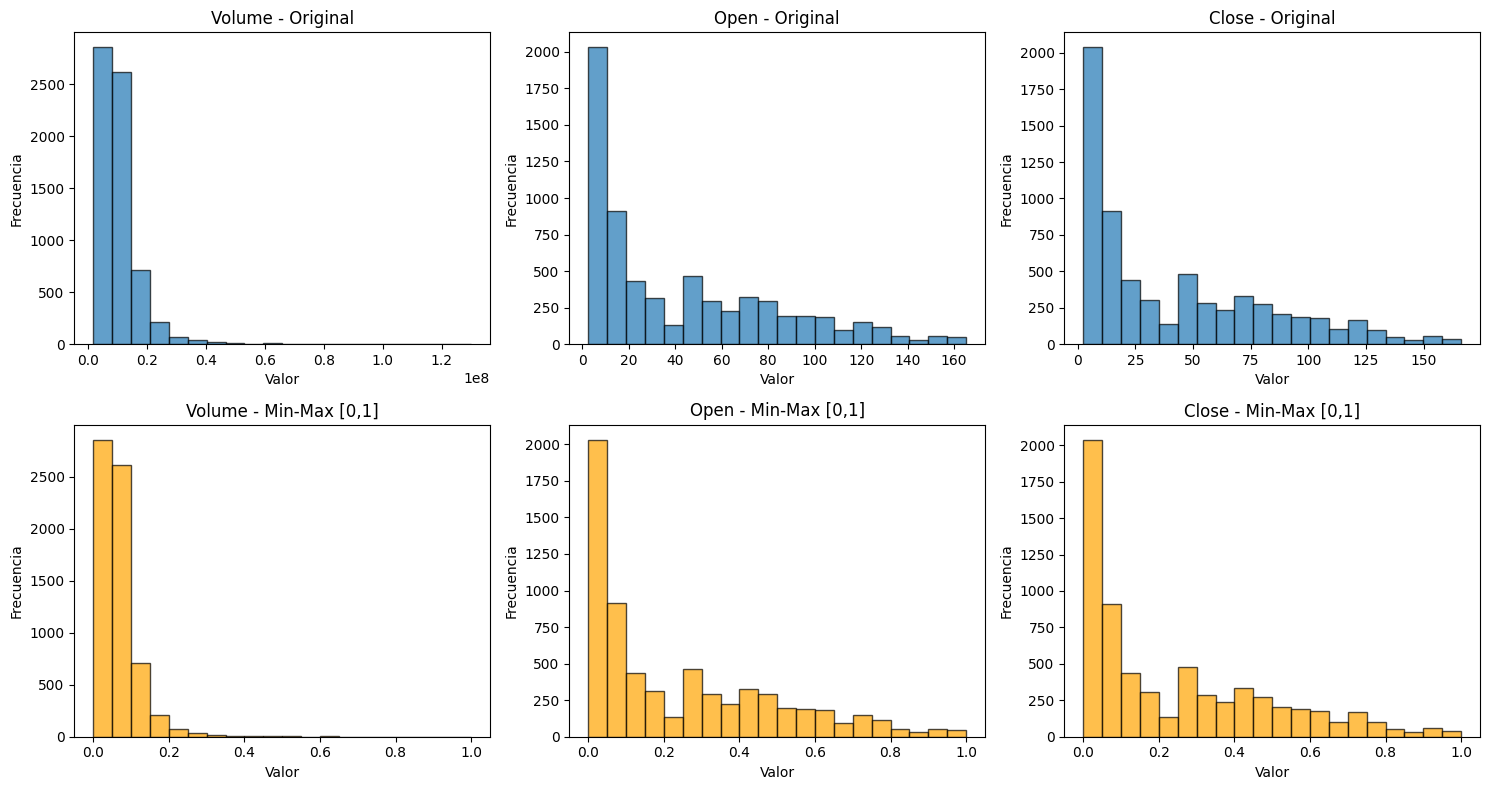

In [74]:
# Visualizar distribuciones antes y después
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    # Original
    axes[0, i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} - Original')
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')
    
    # Normalizado
    axes[1, i].hist(df_minmax[col], bins=20, edgecolor='black', alpha=0.7, color='orange')
    axes[1, i].set_title(f'{col} - Min-Max [0,1]')
    axes[1, i].set_xlabel('Valor')
    axes[1, i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se realizo una estandarizacion sobre las variables Volume, Open y High

---

## Paso 5: Discretización (Binning)

In [75]:
# Bins de igual ancho
df['Variacion_bins_ancho'] = pd.cut(
    df['Variacion'],
    bins=4,
    labels=['Baja fuerte', 'baja', 'alza', 'Alza fuerte']
)

print("Bins de igual ancho (Variacion):")
print(df['Variacion_bins_ancho'].value_counts().sort_index())

Bins de igual ancho (Variacion):
Variacion_bins_ancho
Baja fuerte       2
baja           1013
alza           5525
Alza fuerte      19
Name: count, dtype: int64


In [76]:
# Bins con puntos específicos
df['Variacion_bins_custom'] = pd.cut(
    df['Variacion'],
    bins=[-20, -2.5, 0, 2.5, 20],
    labels=['Baja fuerte', 'baja', 'alza', 'Alza fuerte']
)

print("\nBins personalizados (Variacion):")
print(df['Variacion_bins_custom'].value_counts().sort_index())


Bins personalizados (Variacion):
Variacion_bins_custom
Baja fuerte     273
baja           2943
alza           3013
Alza fuerte     330
Name: count, dtype: int64


In [77]:
# Bins de igual frecuencia (cuartiles)
df['Variacion_cuartiles'] = pd.qcut(
    df['Variacion'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print("\nCuartiles (Variacion):")
print(df['Variacion_cuartiles'].value_counts().sort_index())
print("\nNota: Cada cuartil tiene aproximadamente el mismo número de observaciones")


Cuartiles (Variacion):
Variacion_cuartiles
Q1    1640
Q2    1640
Q3    1639
Q4    1640
Name: count, dtype: int64

Nota: Cada cuartil tiene aproximadamente el mismo número de observaciones


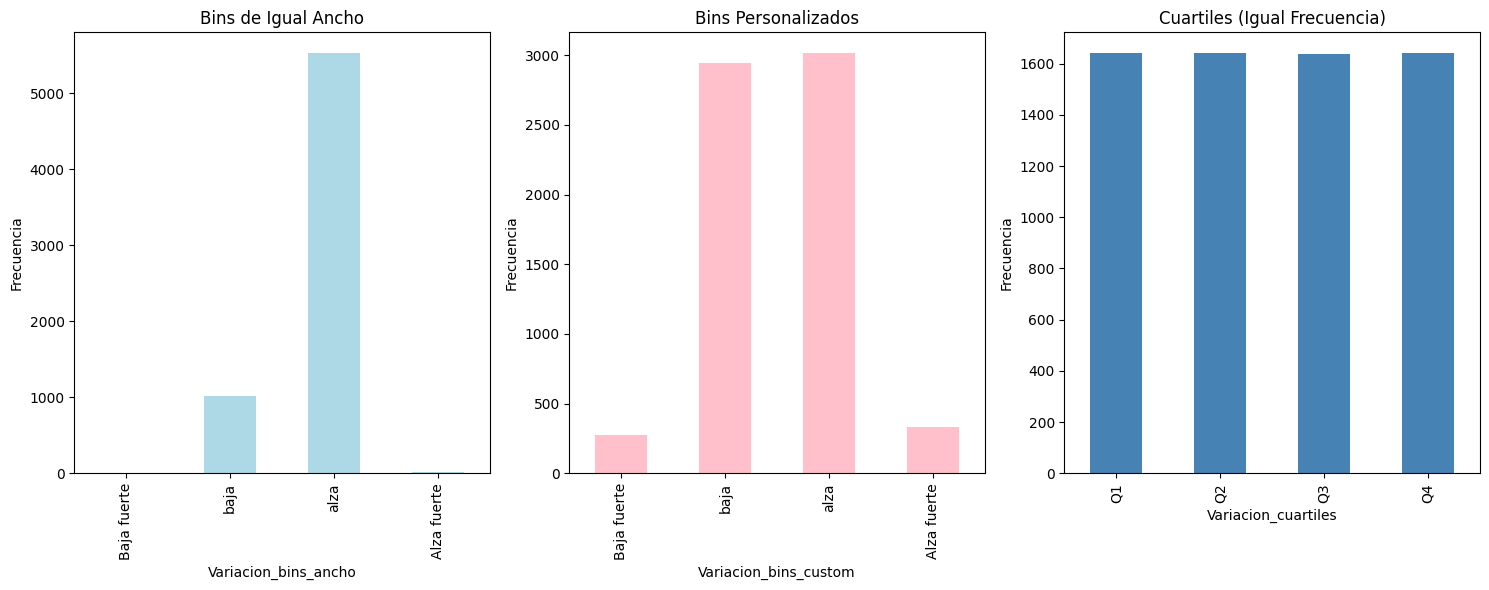

In [78]:
# Visualizar binning
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

df['Variacion_bins_ancho'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_title('Bins de Igual Ancho')
axes[0].set_ylabel('Frecuencia')

df['Variacion_bins_custom'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='pink')
axes[1].set_title('Bins Personalizados')
axes[1].set_ylabel('Frecuencia')

df['Variacion_cuartiles'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Cuartiles (Igual Frecuencia)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se crearon tres separaciones de bins con distintas estrategias sobre la variable 'Variacion'. 
- En el primer caso,  se discretiza por el mismo ancho en todos los bins.
- En el segundo caso, se eligieron los valores -2.5, 0 y 2.5, que son valores tipicos que se considera que el precio presento mucha volatilidad.
- En el tercer caso, se dividieron por cuartiles, dejando aproximadamente la misma cantidad en cada bin.

---
## Integracion de datos
Debido a la falta de una segunda tabla para realizar joins, decidi desistir de esta parte, y realizarla en el Acceso a APIs

---
---

## Acceso a APIs 

Se utilizara la api publica JSONPlaceholder para la practica

In [79]:
import requests

url_users = "https://jsonplaceholder.typicode.com/users"
response_users = requests.get(url_users)

if response_users.status_code  == 200:
    users = response_users.json()
    df_users = pd.DataFrame(users)

df_users.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


In [80]:
url_posts = "https://jsonplaceholder.typicode.com/posts"
response_posts = requests.get(url_posts)

if response_users.status_code  == 200:
    posts = response_posts.json()
    df_posts = pd.DataFrame(posts)

df_posts.head()

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


In [83]:
url_comments = "https://jsonplaceholder.typicode.com/comments"
response_comments = requests.get(url_comments)

if response_users.status_code  == 200:
    comments = response_comments.json()
    df_comments = pd.DataFrame(comments)

df_comments.head()

,postId,id,name,email,body
0,1,1,id labore ex et quam laborum,Eliseo@gardner.biz,laudantium enim quasi est quidem magnam volupt...
1,1,2,quo vero reiciendis velit similique earum,Jayne_Kuhic@sydney.com,est natus enim nihil est dolore omnis voluptat...
2,1,3,odio adipisci rerum aut animi,Nikita@garfield.biz,quia molestiae reprehenderit quasi aspernatur\...
3,1,4,alias odio sit,Lew@alysha.tv,non et atque\noccaecati deserunt quas accusant...
4,1,5,vero eaque aliquid doloribus et culpa,Hayden@althea.biz,harum non quasi et ratione\ntempore iure ex vo...


In [86]:
df_merge = pd.merge(df_posts, df_users, 
                    left_on="userId", 
                    right_on="id")

df_merge[['userId', 'name', 'title']].head(20)

,userId,name,title
0,1,Leanne Graham,sunt aut facere repellat provident occaecati e...
1,1,Leanne Graham,qui est esse
2,1,Leanne Graham,ea molestias quasi exercitationem repellat qui...
3,1,Leanne Graham,eum et est occaecati
4,1,Leanne Graham,nesciunt quas odio
5,1,Leanne Graham,dolorem eum magni eos aperiam quia
6,1,Leanne Graham,magnam facilis autem
7,1,Leanne Graham,dolorem dolore est ipsam
8,1,Leanne Graham,nesciunt iure omnis dolorem tempora et accusan...
9,1,Leanne Graham,optio molestias id quia eum


In [87]:
df_merge = pd.merge(df_posts, df_users, 
                    left_on="userId", 
                    right_on="id")

df_merge[['userId', 'name', 'title']].head()

,userId,name,title
0,1,Leanne Graham,sunt aut facere repellat provident occaecati e...
1,1,Leanne Graham,qui est esse
2,1,Leanne Graham,ea molestias quasi exercitationem repellat qui...
3,1,Leanne Graham,eum et est occaecati
4,1,Leanne Graham,nesciunt quas odio


Join que detalla los Titulos de los posteos de cada usuario

In [84]:
df_count = df_merge.groupby('name')['title'].count().reset_index()
df_count.columns = ['usuario', 'cantidad_posts']

df_count

,usuario,cantidad_posts
0,Chelsey Dietrich,10
1,Clementina DuBuque,10
2,Clementine Bauch,10
3,Ervin Howell,10
4,Glenna Reichert,10
5,Kurtis Weissnat,10
6,Leanne Graham,10
7,Mrs. Dennis Schulist,10
8,Nicholas Runolfsdottir V,10
9,Patricia Lebsack,10


Join que detalla la cantidad de posteos por usuario

Requests:
- Se obtuvieron los datos personales de los usuarios , y se realizo un dataframe con los mismos.
- Se obtuvieron los datos sobre los posteos de los usuarios, y se realizo otro dataframe con los mismos.
- Se obtuvieron los datos sobre los comentarios de los usuarios y se realizo otro dataframe con los mismos
Se realizo un join entre los datos personales y de la cantidad de posteos de cada uno, cumpliendo el punto de joins en el analisis de datos anterior

---
---
## Web Scraping
Se utilizara una pagina de Wikipedia acerca de la poblacion de paises

In [94]:
url = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

df = tables[0]
df.head(10)

,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8232000000,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1417492000,17.2%,1 Jul 2025,Official projection[4],[b]
2,China,1404890000,17.0%,31 Dec 2025,Official estimate[5],[c]
3,United States,341784857,4.1%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,288315089,3.5%,31 Dec 2025,National annual projection[7],NaN
5,Pakistan,241499431,2.9%,1 Mar 2023,2023 census result[8],[e]
6,Nigeria,223800000,2.7%,1 Jul 2023,Official projection[9],NaN
7,Brazil,213421037,2.6%,1 Jul 2025,Official estimate[10],NaN
8,Bangladesh,169828911,2.1%,14 Jun 2022,2022 census result[11],[f]
9,Russia,146028325,1.8%,1 Jan 2025,Official estimate[13],[g]


---
## Tidy data
Se utilizara el dataset creado en el punto anterior, hecho con WebScraping

In [96]:
df = df[['Location', 'Population', 'Date']]

df.columns = ['pais', 'poblacion', 'fecha']

df['poblacion'] = df['poblacion'].astype(str)
df['poblacion'] = df['poblacion'].str.replace(',', '')
df['poblacion'] = df['poblacion'].astype(float)

df['pais'] = df['pais'].str.replace(r'\[.*\]', '', regex=True)

df = df.reset_index(drop=True)

df.head()

,pais,poblacion,fecha
0,World,8.232000e+09,13 Jun 2025
1,India,1.417492e+09,1 Jul 2025
2,China,1.404890e+09,31 Dec 2025
3,United States,3.417849e+08,1 Jul 2025
4,Indonesia,2.883151e+08,31 Dec 2025


Se seleccionaron las columnas utiles, se renombraron, y se limpiaron los datos

In [111]:
df_wide = df.head(10).copy()

df_wide['año'] = 2023

# creamos otra versión con otro año
df_extra = df_wide.copy()
df_extra['año'] = 2022
df_extra['poblacion'] = df_extra['poblacion'] * 0.98

# unimos
df_concat = pd.concat([df_wide, df_extra])

df_pivot = df_concat.pivot(index='pais', 
                          columns='año', 
                          values='poblacion')

df_pivot



año,2022,2023
pais,,
Bangladesh,1.664323e+08,1.698289e+08
Brazil,2.091526e+08,2.134210e+08
China,1.376792e+09,1.404890e+09
India,1.389142e+09,1.417492e+09
Indonesia,2.825488e+08,2.883151e+08
Nigeria,2.193240e+08,2.238000e+08
Pakistan,2.366694e+08,2.414994e+08
Russia,1.431078e+08,1.460283e+08
United States,3.349492e+08,3.417849e+08


In [110]:
df_long = df_pivot.reset_index().melt(
    id_vars='pais',
    var_name='año',
    value_name='poblacion'
)
df_long

,pais,año,poblacion
0,Bangladesh,2022,1.664323e+08
1,Brazil,2022,2.091526e+08
2,China,2022,1.376792e+09
3,India,2022,1.389142e+09
4,Indonesia,2022,2.825488e+08
5,Nigeria,2022,2.193240e+08
6,Pakistan,2022,2.366694e+08
7,Russia,2022,1.431078e+08
8,United States,2022,3.349492e+08
9,World,2022,8.067360e+09


A partir del dataset original en formato tidy, se generó un dataset en formato wide mediante pivot, y posteriormente se revirtió a formato long utilizando melt.